# Singapore MOH Weekly Infectious Disease Bulletin

This notebook demonstrates how to access the **Weekly Infectious Disease Bulletin Cases** dataset published by the Singapore **Ministry of Health (MOH)** via [data.gov.sg](https://data.gov.sg/).

**Data Source:**
- **Dataset:** [Weekly Infectious Disease Bulletin Cases](https://data.gov.sg/datasets/d_ca168b2cb763640d72c4600a68f9909e)
- **API:** data.gov.sg CKAN datastore REST API
- **Coverage:** ~30+ notifiable diseases by epidemiological week (2012–2022)

**Coverage:**
- **Geographic:** National (Singapore)
- **Temporal:** 2012–2022 (epidemiological weeks)
- **Diseases:** Dengue, Chikungunya, Cholera, Avian Influenza, Hepatitis, and many more

> Singapore is a world reference in dengue surveillance.  
> This data enables direct comparisons with Brazilian arbovirus data (e.g. InfoDengue).

**Requirements:**
```bash
pip install pandas matplotlib seaborn epidatasets
```

## 1. Setup and Imports

In [1]:
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
%matplotlib inline

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)

print(f"Imports completed. {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Imports completed. 2026-06-22 15:32


## 2. Initialize the Accessor

You can instantiate via the unified registry with `get_source("singapore_moh")` or directly.

In [2]:
from epidatasets.sources.singapore_moh import SingaporeMOHAccessor

moh = SingaporeMOHAccessor()

print(f"Source      : {moh.source_name}")
print(f"Description : {moh.source_description}")
print(f"Portal      : {moh.source_url}")

Source      : singapore_moh
Description : Weekly Infectious Disease Bulletin Cases from the Singapore Ministry of Health (MOH) via data.gov.sg, covering ~30+ notifiable diseases by epidemiological week (2012-2022).
Portal      : https://data.gov.sg/datasets/d_ca168b2cb763640d72c4600a68f9909e


In [3]:
countries = moh.list_countries()
print(countries.to_string(index=False))

country_code country_name
          SG    Singapore


## 3. Notifiable Diseases

The bulletin tracks ~30+ notifiable infectious diseases.  
Let's list all diseases covered, along with how many epidemiological weeks each appears in.

In [4]:
diseases = moh.list_diseases()
print(f"Total diseases: {len(diseases)}")
display(diseases.head(15))

Total diseases: 46


,disease,record_count
0,Acute Viral Hepatitis A,313
1,Acute Viral Hepatitis E,313
2,Acute Viral hepatitis B,574
3,Acute Viral hepatitis C,574
4,Avian Influenza,574
5,Botulism,313
6,Campylobacter enteritis,313
7,Campylobacterenterosis,261
8,Chikungunya,313
9,Chikungunya Fever,261


## 4. Dengue Fever — Weekly Time Series

Singapore experienced major dengue outbreaks in 2013, 2015, 2019, and 2020.  
Let's fetch weekly Dengue Fever cases for those epidemic years.

In [5]:
dengue = moh.get_cases(disease='Dengue Fever', years=[2019, 2020, 2021, 2022])
print(f"Dengue records: {len(dengue)}")
display(dengue.head(10))

Dengue records: 209


,epi_week,disease,no._of_cases,year
0,2019-W01,Dengue Fever,205,2019
1,2019-W02,Dengue Fever,245,2019
2,2019-W03,Dengue Fever,207,2019
3,2019-W04,Dengue Fever,221,2019
4,2019-W05,Dengue Fever,179,2019
5,2019-W06,Dengue Fever,135,2019
6,2019-W07,Dengue Fever,232,2019
7,2019-W08,Dengue Fever,181,2019
8,2019-W09,Dengue Fever,156,2019
9,2019-W10,Dengue Fever,133,2019


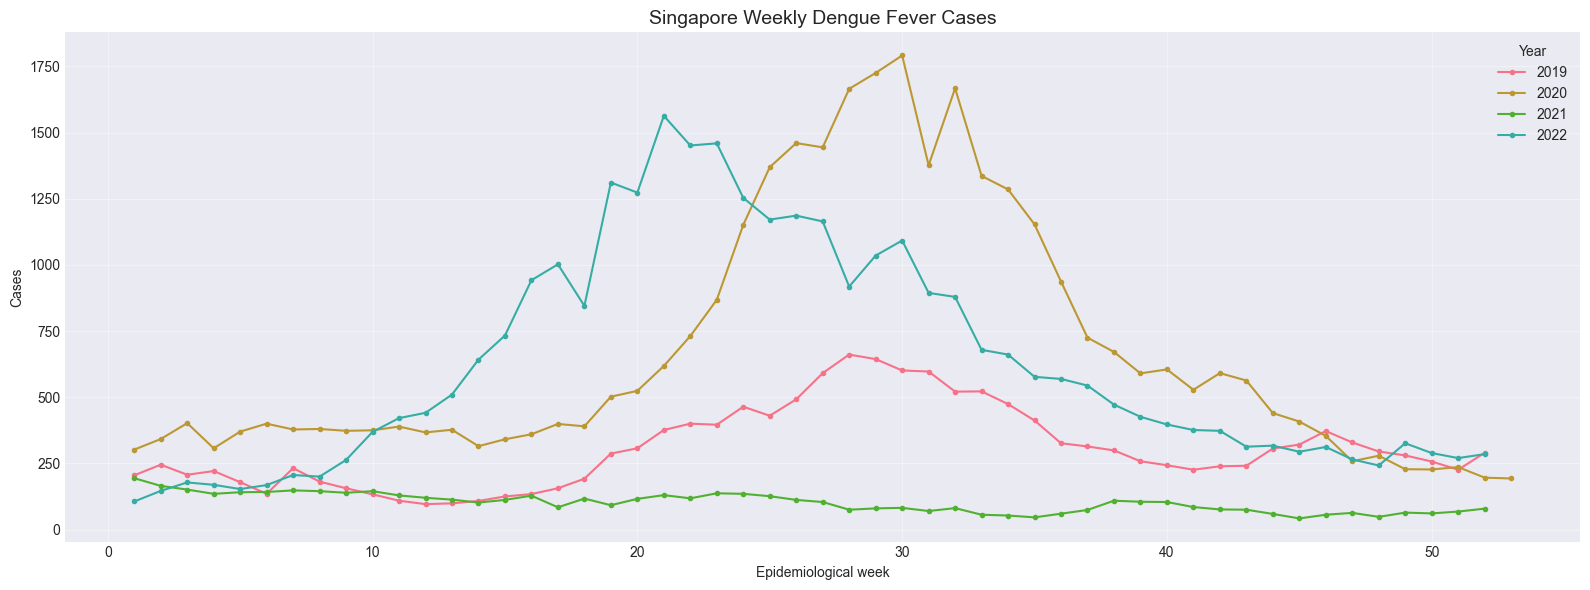

In [6]:
fig, ax = plt.subplots(figsize=(16, 6))
for year, grp in dengue.groupby('year'):
    week = grp['epi_week'].str.extract(r'(\d+)$')[0].astype(int)
    ax.plot(week, grp['no._of_cases'], marker='.', label=str(year))

ax.set_title('Singapore Weekly Dengue Fever Cases', fontsize=14)
ax.set_xlabel('Epidemiological week')
ax.set_ylabel('Cases')
ax.legend(title='Year')
plt.tight_layout()
plt.show()

### Annual dengue totals

2020 was Singapore's largest dengue outbreak on record (>35 000 cases).

,year,total_cases
0,2019,15910
1,2020,35261
2,2021,5251
3,2022,32130


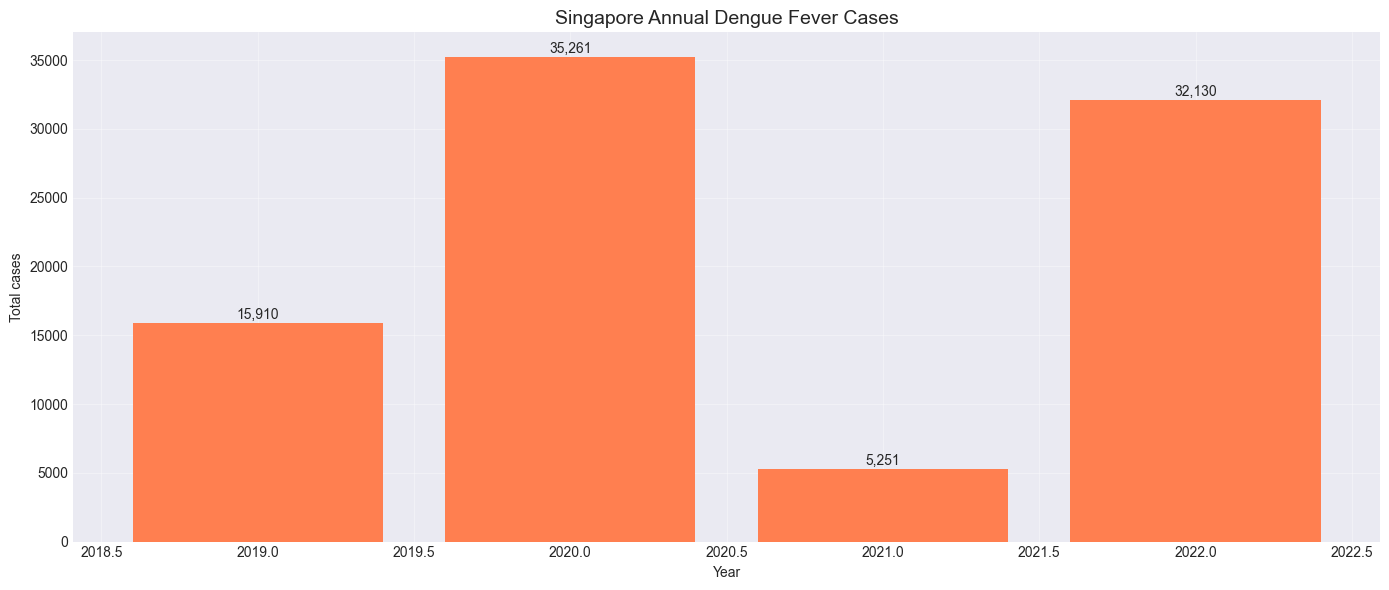

In [7]:
annual = dengue.groupby('year', as_index=False)['no._of_cases'].sum()
annual.columns = ['year', 'total_cases']
display(annual)

fig, ax = plt.subplots()
ax.bar(annual['year'], annual['total_cases'], color='coral')
ax.set_title('Singapore Annual Dengue Fever Cases', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Total cases')
for i, row in annual.iterrows():
    ax.text(row['year'], row['total_cases'] + 300, f"{int(row['total_cases']):,}",
            ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## 5. Comparing Arboviruses

Dengue, Chikungunya, and Zika are all mosquito-borne.  
Let's compare their weekly trends in 2020.

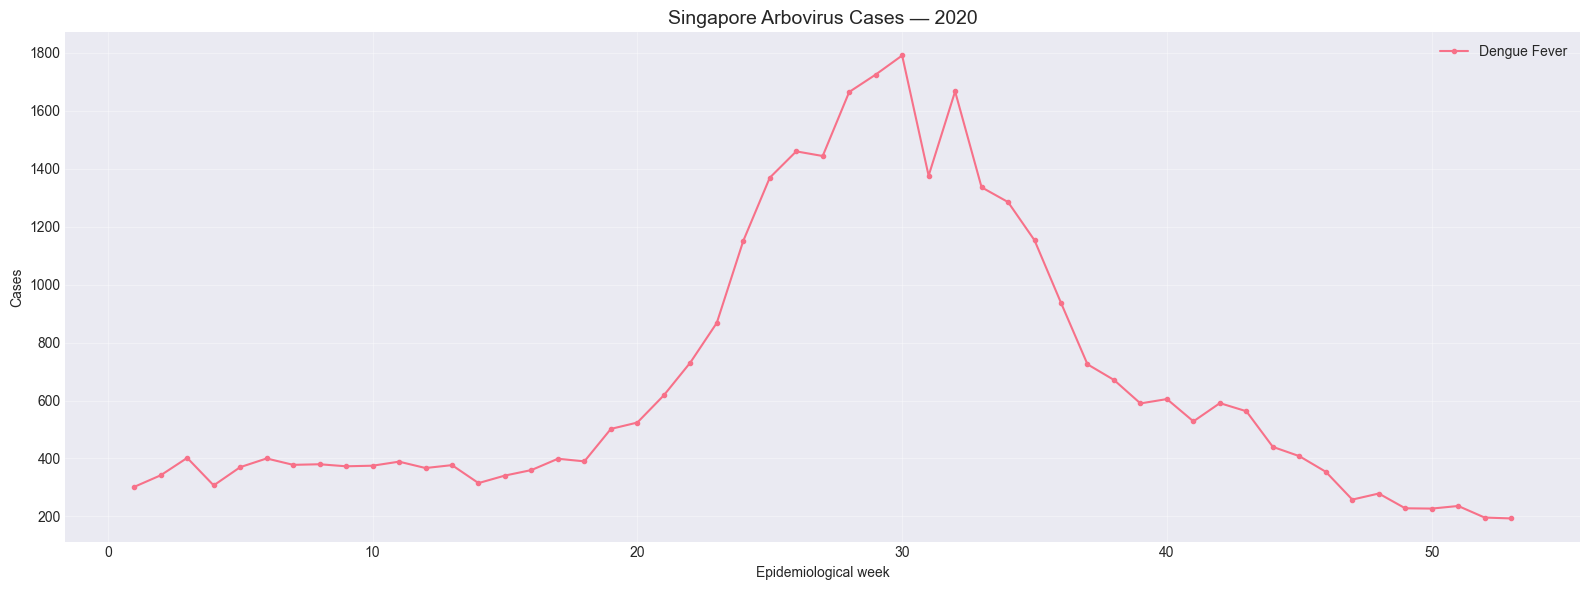

In [8]:
arboviruses = moh.get_cases(
    disease=['Dengue Fever', 'Chikungunya Fever', 'Zika Virus Infection'],
    years=[2020],
)

fig, ax = plt.subplots(figsize=(16, 6))
for disease, grp in arboviruses.groupby('disease'):
    week = grp['epi_week'].str.extract(r'(\d+)$')[0].astype(int)
    ax.plot(week, grp['no._of_cases'], marker='.', label=disease)

ax.set_title('Singapore Arbovirus Cases — 2020', fontsize=14)
ax.set_xlabel('Epidemiological week')
ax.set_ylabel('Cases')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Disease Summary

Total cases across all diseases and years, ranked by cumulative burden.

,disease,no._of_cases
0,Dengue Fever,164023
1,"Hand, Foot Mouth Disease",161482
2,HFMD,73927
3,Salmonellosis(non-enteric fevers),18996
4,Mumps,4572
5,Campylobacter enteritis,3179
6,Campylobacterenterosis,2138
7,Chikungunya Fever,1348
8,Pneumococcal Disease (invasive),1297
9,Measles,677


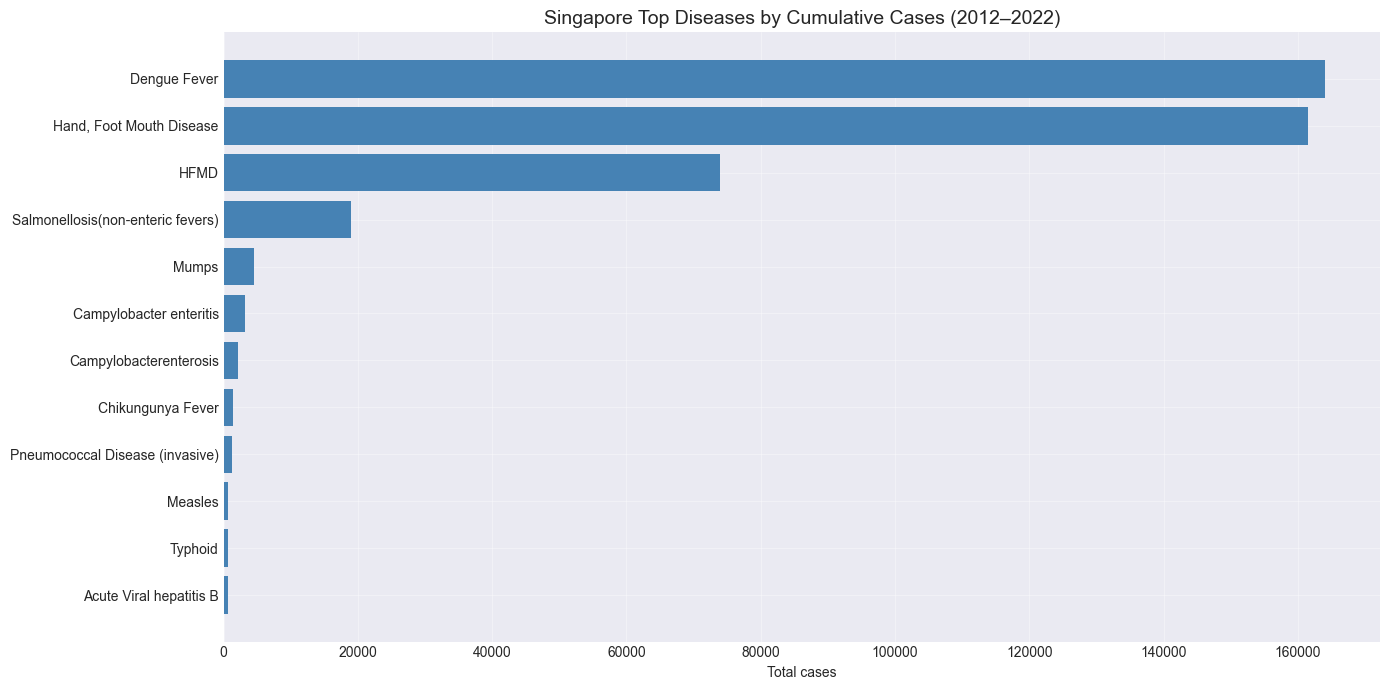

In [9]:
summary = moh.get_summary(by='disease')
display(summary.head(15))

fig, ax = plt.subplots(figsize=(14, 7))
top = summary.head(12)
ax.barh(top['disease'][::-1], top['no._of_cases'][::-1], color='steelblue')
ax.set_title('Singapore Top Diseases by Cumulative Cases (2012–2022)', fontsize=14)
ax.set_xlabel('Total cases')
plt.tight_layout()
plt.show()

## 7. Summary

| Method | Description |
|--------|-------------|
| `list_diseases()` | Distinct diseases with record counts |
| `get_cases(disease, years)` | Weekly case counts, filterable |
| `get_dengue_cases(years)` | Convenience wrapper for Dengue + DHF |
| `get_summary(by='disease')` | Aggregate cases by disease or year |
| `list_countries()` | Country coverage (Singapore) |

**Related notebooks:**
- [Singapore NEA Dengue Data](27_Singapore_NEA_Dengue_Data.ipynb) — dengue clusters, breeding habitats & vector control.
- [InfoDengue Brazilian Arbovirus Surveillance](18_InfoDengue_Brazilian_Arbovirus_Surveillance.ipynb) — compare with Brazilian dengue data.